In [1]:
!pip install tensorflow tensorflow-hub matplotlib pillow

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files

uploaded = files.upload()


Saving style.jpg to style.jpg
Saving content.jpg to content.jpg


In [5]:
def load_image(image_path, max_dim=512):
    img = Image.open(image_path).convert("RGB")

    scale = max_dim / max(img.size)
    new_size = (
        round(img.size[0] * scale),
        round(img.size[1] * scale)
    )

    img = img.resize(new_size)
    img = np.array(img).astype(np.float32) / 255.0

    return img


content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

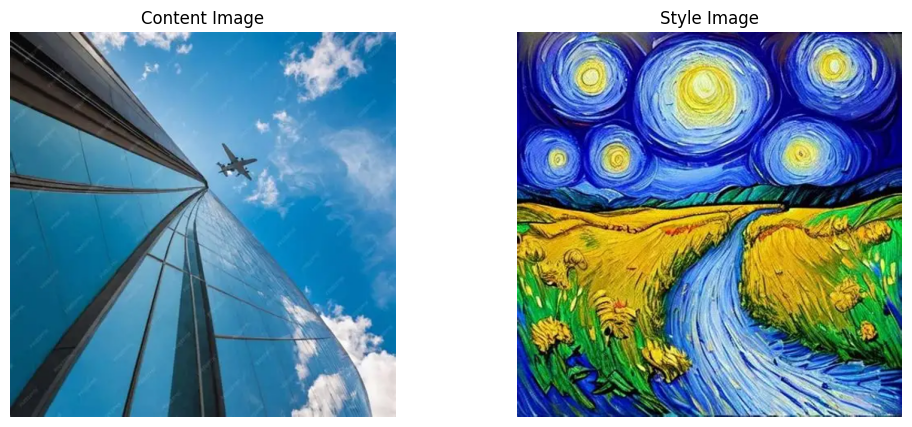

In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(content_image)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(style_image)
plt.title("Style Image")
plt.axis("off")

plt.show()

In [7]:
model = hub.load(
    "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"
)

print("Model loaded successfully!")

Model loaded successfully!


In [8]:
content_tensor = tf.constant(content_image)
style_tensor = tf.constant(style_image)

content_tensor = content_tensor[tf.newaxis, :]
style_tensor = style_tensor[tf.newaxis, :]

In [9]:
stylized_image = model(
    content_tensor,
    style_tensor
)[0]

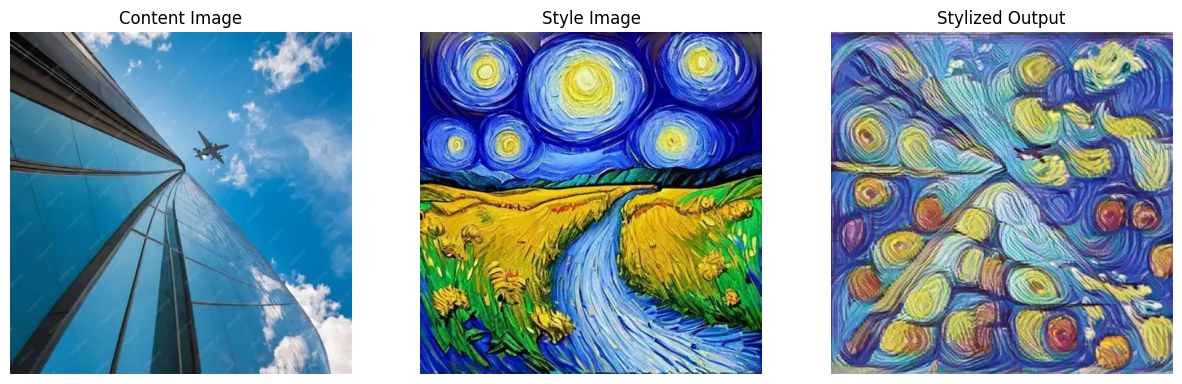

In [11]:
# Remove the extra batch dimension
stylized_image = stylized_image[0]

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(content_image)
plt.title("Content Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(style_image)
plt.title("Style Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(stylized_image)
plt.title("Stylized Output")
plt.axis("off")

plt.show()

In [12]:
!pip install torch torchvision

In [13]:
import torch
import torchvision
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu130
CUDA available: True


In [14]:
import torch
import torchvision.transforms as transforms
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cuda


In [15]:
latent_dim = 100

z = torch.randn(16, latent_dim, 1, 1).to(device)

print("Latent vector shape:", z.shape)

Latent vector shape: torch.Size([16, 100, 1, 1])


In [16]:
output_image = Image.fromarray(
    np.uint8(stylized_image.numpy() * 255)
)

output_image.save("stylized_output.jpg")

print("Image saved successfully!")

Image saved successfully!


In [17]:
from google.colab import files

files.download("stylized_output.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>